<a href="https://colab.research.google.com/github/DeepanshuSharma1607/tech_stuck/blob/main/pytorch_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marquis03/bean-leaf-lesions-classification")

print("Path to dataset files:", path)

100%|██████████| 155M/155M [00:08<00:00, 18.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/bean-leaf-lesions-classification/versions/1


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader , Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
path = os.path.join()

'/root/.cache/kagglehub/datasets/marquis03/bean-leaf-lesions-classification/versions/1'

In [ ]:
os.listdir(path)

['val.csv', 'classname.txt', 'train.csv', 'train', 'val']

In [ ]:
train_df = pd.read_csv(os.path.join(path,"train.csv"))
val_df = pd.read_csv(os.path.join(path,"val.csv"))

train_df['image:FILE'] = path+'/'+train_df['image:FILE']
val_df['image:FILE'] = path+'/'+val_df['image:FILE']
train_df.head()

,image:FILE,category
0,/root/.cache/kagglehub/datasets/marquis03/bean...,0
1,/root/.cache/kagglehub/datasets/marquis03/bean...,0
2,/root/.cache/kagglehub/datasets/marquis03/bean...,0
3,/root/.cache/kagglehub/datasets/marquis03/bean...,0
4,/root/.cache/kagglehub/datasets/marquis03/bean...,0


In [ ]:
val_df

,image:FILE,category
0,/root/.cache/kagglehub/datasets/marquis03/bean...,0
1,/root/.cache/kagglehub/datasets/marquis03/bean...,0
2,/root/.cache/kagglehub/datasets/marquis03/bean...,0
3,/root/.cache/kagglehub/datasets/marquis03/bean...,0
4,/root/.cache/kagglehub/datasets/marquis03/bean...,0
...,...,...
128,/root/.cache/kagglehub/datasets/marquis03/bean...,2
129,/root/.cache/kagglehub/datasets/marquis03/bean...,2
130,/root/.cache/kagglehub/datasets/marquis03/bean...,2
131,/root/.cache/kagglehub/datasets/marquis03/bean...,2


In [ ]:
train_df['category'].value_counts()

,count
category,
2,348
1,345
0,341


In [ ]:
train_df.shape,val_df.shape

((1034, 2), (133, 2))

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataSet(Dataset):
  def __init__(self , dataframe , transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self , idx):
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = (self.transform(image)/255.0).to(device)
    return image , label

In [ ]:
train_dataset = CustomImageDataSet(dataframe=train_df,transform=transform)
val_dataset = CustomImageDataSet(dataframe=val_df,transform=transform)

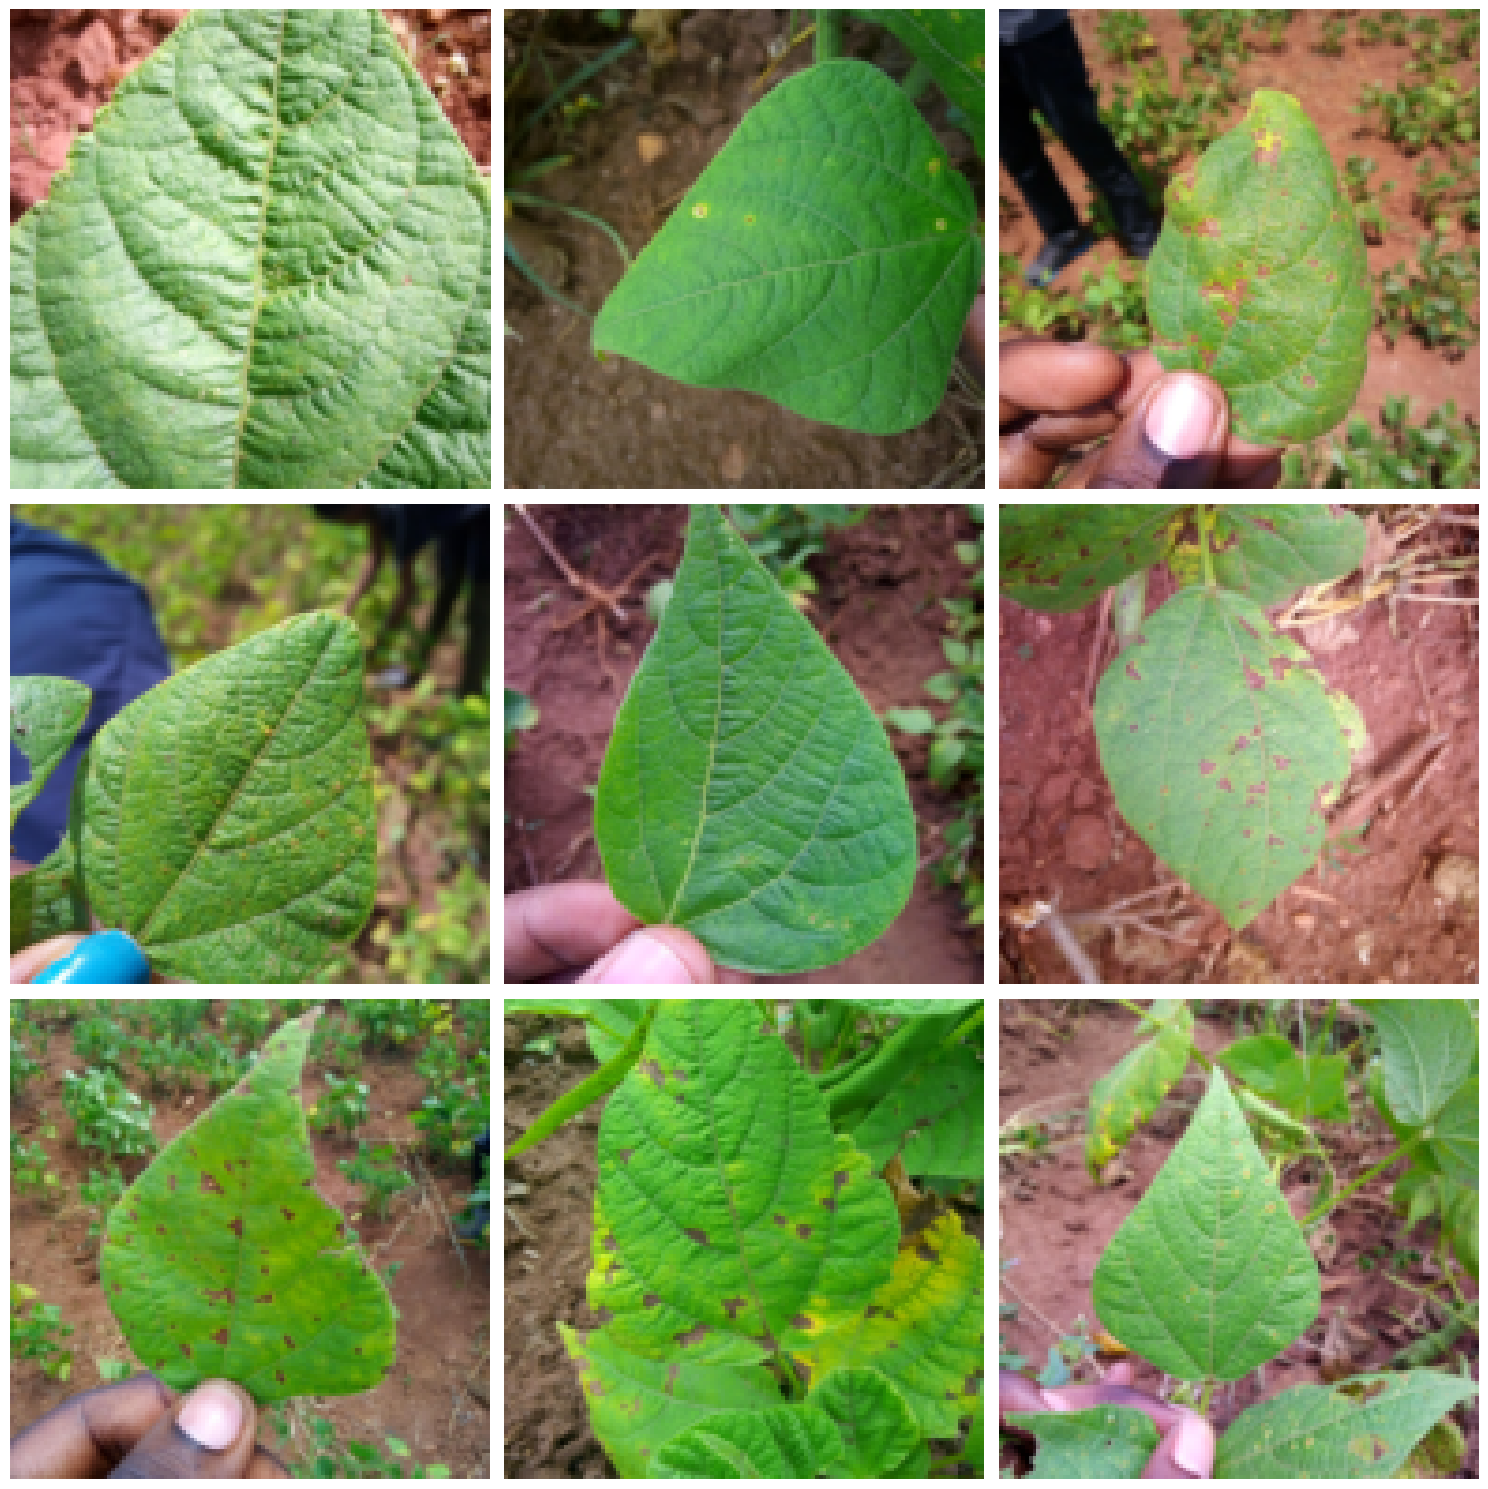

In [ ]:
n_rows = 3
n_cols = 3
fig , axes = plt.subplots(n_rows,n_cols,figsize=(15,15))

for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        axes[row, col].imshow((image*255.0).squeeze().permute(1, 2, 0))
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
LR = 1e-4
BATCH_SIZE = 4
EPOCHS = 15

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [ ]:
googlenet_model = models.googlenet(weights='DEFAULT')

In [ ]:
for param in googlenet_model.parameters():
    param.requires_grad = True

In [ ]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [ ]:
num_classes = len(train_df["category"].unique())
num_classes

3

In [ ]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features,num_classes)

In [ ]:
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [ ]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
loss  = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(),lr=LR)

In [ ]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for x , y in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(x)
    train_loss = loss(outputs,y)
    train_loss.backward()

    total_loss_train += train_loss.item()
    train_acc = (torch.argmax(outputs,axis=1) == y).sum().item()
    total_acc_train +=train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))

  print(f"""EPOCH no. {epoch+1}/{EPOCHS}
  Training Loss: {total_loss_train_plot[-1]}
  Training Accuracy: {total_acc_train_plot[-1]}
        """)

EPOCH no. 1/15
  Training Loss: 0.2157
  Training Accuracy: 61.412
        
EPOCH no. 2/15
  Training Loss: 0.1628
  Training Accuracy: 73.2108
        
EPOCH no. 3/15
  Training Loss: 0.1365
  Training Accuracy: 80.0774
        
EPOCH no. 4/15
  Training Loss: 0.1257
  Training Accuracy: 80.4642
        
EPOCH no. 5/15
  Training Loss: 0.111
  Training Accuracy: 83.2689
        
EPOCH no. 6/15
  Training Loss: 0.0983
  Training Accuracy: 85.7834
        
EPOCH no. 7/15
  Training Loss: 0.0849
  Training Accuracy: 87.8143
        
EPOCH no. 8/15
  Training Loss: 0.0834
  Training Accuracy: 89.942
        
EPOCH no. 9/15
  Training Loss: 0.0632
  Training Accuracy: 92.2631
        
EPOCH no. 10/15
  Training Loss: 0.0603
  Training Accuracy: 92.8433
        
EPOCH no. 11/15
  Training Loss: 0.0596
  Training Accuracy: 92.7466
        
EPOCH no. 12/15
  Training Loss: 0.0532
  Training Accuracy: 93.0368
        
EPOCH no. 13/15
  Training Loss: 0.0412
  Training Accuracy: 95.7447
       

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for x , y in val_loader:
    prediction = googlenet_model(x)
    acc = (torch.argmax(prediction,axis=1) == y).sum().item()
    total_acc_test += acc

In [ ]:
print(round(total_acc_test/val_dataset.__len__(),4))

0.4586


In [ ]:
googlenet_model = models.googlenet(weights='DEFAULT')

In [ ]:
for param in googlenet_model.parameters():
    param.requires_grad = False

In [ ]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features,num_classes)

In [ ]:
googlenet_model.fc.requires_grad = True

In [ ]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for x , y in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(x)
    train_loss = loss(outputs,y)
    train_loss.backward()

    total_loss_train += train_loss.item()
    train_acc = (torch.argmax(outputs,axis=1) == y).sum().item()
    total_acc_train +=train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))

  print(f"""EPOCH no. {epoch+1}/{EPOCHS}
  Training Loss: {total_loss_train_plot[-1]}
  Training Accuracy: {total_acc_train_plot[-1]}
        """)

EPOCH no. 1/15
  Training Loss: 0.2902
  Training Accuracy: 33.4623
        
EPOCH no. 2/15
  Training Loss: 0.2931
  Training Accuracy: 29.1103
        
EPOCH no. 3/15
  Training Loss: 0.2889
  Training Accuracy: 34.236
        
EPOCH no. 4/15
  Training Loss: 0.2904
  Training Accuracy: 34.1393
        
EPOCH no. 5/15
  Training Loss: 0.2886
  Training Accuracy: 35.3965
        
EPOCH no. 6/15
  Training Loss: 0.289
  Training Accuracy: 34.236
        
EPOCH no. 7/15
  Training Loss: 0.2896
  Training Accuracy: 32.882
        
EPOCH no. 8/15
  Training Loss: 0.2883
  Training Accuracy: 36.5571
        
EPOCH no. 9/15
  Training Loss: 0.2893
  Training Accuracy: 33.6557
        
EPOCH no. 10/15
  Training Loss: 0.2889
  Training Accuracy: 35.0097
        
EPOCH no. 11/15
  Training Loss: 0.2902
  Training Accuracy: 32.9787
        
EPOCH no. 12/15
  Training Loss: 0.2885
  Training Accuracy: 34.3327
        
EPOCH no. 13/15
  Training Loss: 0.286
  Training Accuracy: 37.8143
        


In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for x , y in val_loader:
    prediction = googlenet_model(x)
    acc = (torch.argmax(prediction,axis=1) == y).sum().item()
    total_acc_test += acc

In [ ]:
print(round(total_acc_test/val_dataset.__len__(),4))

0.4586
